
# Flutter aeroelástico de uma placa trapezoidal com FE + DLM

Este notebook organiza o estudo em sete capítulos:

1. geometria da placa e restrições;
2. discretização trapezoidal;
3. modelo estrutural e estudo de convergência das frequências naturais;
4. modelo aerodinâmico DLM e escolha da biblioteca;
5. acoplamento estrutura–aerodinâmica;
6. procedimento para encontrar a velocidade de flutter e interpretação dos *branches*;
7. resultados finais: frequências naturais e velocidade de flutter.

> **Dependência externa**: este notebook usa a biblioteca `PanelAero`. Para instalar:
>
> ```bash
> pip install PanelAero numpy scipy matplotlib
> ```



## Preparação do ambiente

Antes dos capítulos, reunimos em um único bloco as funções auxiliares usadas ao longo do notebook.
Elas implementam:

- a malha estrutural trapezoidal;
- o elemento de placa de Mindlin QUAD4;
- a montagem das matrizes estruturais $K$ e $M$;
- os operadores de acoplamento modal;
- a montagem do modelo aerodinâmico DLM via `PanelAero`;
- o algoritmo de *branch tracking* para o flutter scan.

Os capítulos seguintes usam essas funções para executar cada etapa do estudo.


In [22]:

"""
FE + PanelAero DLM coupling for flutter analysis
with branch tracking and diagnostics.

Main fixes applied
------------------
1) Half-wing model uses xz_symmetry=True by default.
2) DLM branch tracking is performed across airspeed steps.
3) All modal branches are stored and plotted, not only max Re(lambda).
4) The aero frequency k = omega/U is monitored; clipping is reported.
5) The flutter estimate is taken from the first branch that crosses Re(lambda)=0.
6) A structural-only sanity check is printed first.

Notes
-----
- This remains a p-k-like solver: the aerodynamic matrix is frozen at the current omega/U,
  then the complex state-space eigenproblem is solved iteratively.
- PanelAero provides the DLM AIC. The quality of the final flutter result still depends on
  your structural model, aero mesh, coupling assumptions, and the chosen sign conventions.
- The default signs below are chosen to avoid the pathological "always positive Re(lambda)"
  behavior that appeared earlier. They are exposed as parameters for diagnostics.
"""

import warnings
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import lil_matrix
from scipy.sparse.linalg import eigsh

try:
    from panelaero import DLM
except Exception as exc:
    raise ImportError(
        "PanelAero is required. Install it with: pip install PanelAero\n"
        f"Original import error: {exc}"
    )

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True


# ============================================================
# 1) GEOMETRY AND MESHES
# ============================================================

def chord_linear(y, b, c_root, c_tip):
    return c_root + (c_tip - c_root) * (y / b)


def generate_structured_trapezoidal_mesh(b, c_root, c_tip, nx, ny):
    y_nodes = np.linspace(0.0, b, ny + 1)

    nodes = []
    node_id = {}

    def add_node(x, y, z=0.0):
        key = (round(float(x), 12), round(float(y), 12), round(float(z), 12))
        if key in node_id:
            return node_id[key]
        idx = len(nodes)
        nodes.append([x, y, z])
        node_id[key] = idx
        return idx

    grid = []
    for j in range(ny + 1):
        y = y_nodes[j]
        c = chord_linear(y, b, c_root, c_tip)
        row = []
        for i in range(nx + 1):
            x = (i / nx) * c
            row.append(add_node(x, y))
        grid.append(row)

    quads = []
    for j in range(ny):
        for i in range(nx):
            quads.append([grid[j][i], grid[j][i + 1], grid[j + 1][i + 1], grid[j + 1][i]])

    return np.array(nodes, dtype=float), quads, {"grid": grid, "y_nodes": y_nodes}


def plot_mesh(nodes, quads, ax=None, title="Mesh"):
    if ax is None:
        fig, ax = plt.subplots()
    for q in quads:
        xy = nodes[np.array(q + [q[0]]), :2]
        ax.plot(xy[:, 0], xy[:, 1], "k-", lw=0.4)
    ax.set_aspect("equal")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(title)
    return ax


def polygon_area_2d(poly):
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def generate_aero_boxes(b, c_root, c_tip, nx, ny):
    y = np.linspace(0.0, b, ny + 1)
    boxes = []

    for j in range(ny):
        y1, y2 = y[j], y[j + 1]
        c1 = chord_linear(y1, b, c_root, c_tip)
        c2 = chord_linear(y2, b, c_root, c_tip)

        xs1 = np.linspace(0.0, c1, nx + 1)
        xs2 = np.linspace(0.0, c2, nx + 1)

        for i in range(nx):
            p1 = np.array([xs1[i],   y1, 0.0])
            p2 = np.array([xs1[i+1], y1, 0.0])
            p3 = np.array([xs2[i+1], y2, 0.0])
            p4 = np.array([xs2[i],   y2, 0.0])
            boxes.append(np.vstack([p1, p2, p3, p4]))

    return boxes


def box_geometry(box):
    p1, p2, p3, p4 = box

    P1 = p1 + 0.25 * (p2 - p1)
    P3 = p4 + 0.25 * (p3 - p4)

    offset_l = 0.5 * (P1 + P3)

    k1 = p1 + 0.50 * (p2 - p1)
    k3 = p4 + 0.50 * (p3 - p4)
    offset_k = 0.5 * (k1 + k3)

    j1 = p1 + 0.75 * (p2 - p1)
    j3 = p4 + 0.75 * (p3 - p4)
    offset_j = 0.5 * (j1 + j3)

    forcep = offset_k

    v1 = p2 - p1
    v2 = p4 - p1
    n = np.cross(v1, v2)
    nn = np.linalg.norm(n)
    if nn < 1e-12:
        raise ValueError("Degenerate aero panel.")
    N = n / nn
    if N[2] < 0.0:
        N = -N

    chord_root = np.linalg.norm(p2 - p1)
    chord_tip  = np.linalg.norm(p3 - p4)
    chord_mid = 0.5 * (chord_root + chord_tip)

    area = polygon_area_2d(box[:, :2])

    return {
        "box": box,
        "offset_l": offset_l,
        "offset_k": offset_k,
        "offset_j": offset_j,
        "offset_P1": P1,
        "offset_P3": P3,
        "forcep": forcep,
        "N": N,
        "A": area,
        "l": chord_mid,
    }


def build_panelaero_aerogrid(aero_geos):
    return {
        "offset_l": np.array([g["offset_l"] for g in aero_geos], dtype=float),
        "offset_k": np.array([g["offset_k"] for g in aero_geos], dtype=float),
        "offset_j": np.array([g["offset_j"] for g in aero_geos], dtype=float),
        "offset_P1": np.array([g["offset_P1"] for g in aero_geos], dtype=float),
        "offset_P3": np.array([g["offset_P3"] for g in aero_geos], dtype=float),
        "N": np.array([g["N"] for g in aero_geos], dtype=float),
        "A": np.array([g["A"] for g in aero_geos], dtype=float),
        "l": np.array([g["l"] for g in aero_geos], dtype=float),
        "n": len(aero_geos),
    }


# ============================================================
# 2) MINDLIN QUAD4 STRUCTURAL ELEMENT
# ============================================================

def quad4_shape(xi, eta):
    N = 0.25 * np.array([
        (1 - xi) * (1 - eta),
        (1 + xi) * (1 - eta),
        (1 + xi) * (1 + eta),
        (1 - xi) * (1 + eta)
    ], dtype=float)

    dN_dxi = 0.25 * np.array([
        -(1 - eta),
        +(1 - eta),
        +(1 + eta),
        -(1 + eta)
    ], dtype=float)

    dN_deta = 0.25 * np.array([
        -(1 - xi),
        -(1 + xi),
        +(1 + xi),
        +(1 - xi)
    ], dtype=float)

    return N, dN_dxi, dN_deta


def quad4_mindlin_element_matrices(xy, E, nu, h, rho, kappa=5/6):
    D = E * h**3 / (12 * (1 - nu**2))
    Db = D * np.array([[1, nu, 0],
                       [nu, 1, 0],
                       [0, 0, (1 - nu)/2]], dtype=float)

    G = E / (2 * (1 + nu))
    Ds = (kappa * G * h) * np.eye(2)

    Ke = np.zeros((12, 12), dtype=float)
    Me = np.zeros((12, 12), dtype=float)

    gp = 1.0 / np.sqrt(3.0)
    gauss_2x2 = [(-gp, -gp, 1.0), ( gp, -gp, 1.0),
                 ( gp,  gp, 1.0), (-gp,  gp, 1.0)]

    mw = rho * h
    mr = rho * (h**3) / 12.0

    for xi, eta, wgt in gauss_2x2:
        N, dN_dxi, dN_deta = quad4_shape(xi, eta)

        J = np.array([
            [dN_dxi @ xy[:, 0], dN_deta @ xy[:, 0]],
            [dN_dxi @ xy[:, 1], dN_deta @ xy[:, 1]]
        ], dtype=float)

        detJ = np.linalg.det(J)
        if detJ <= 0:
            raise ValueError("Structural element with det(J) <= 0.")

        invJ = np.linalg.inv(J)
        dN_dx = invJ[0, 0] * dN_dxi + invJ[0, 1] * dN_deta
        dN_dy = invJ[1, 0] * dN_dxi + invJ[1, 1] * dN_deta

        Bb = np.zeros((3, 12), dtype=float)
        for i in range(4):
            txi = 3*i + 1
            tyi = 3*i + 2

            Bb[0, txi] = dN_dx[i]
            Bb[1, tyi] = dN_dy[i]
            Bb[2, txi] = dN_dy[i]
            Bb[2, tyi] = dN_dx[i]

        Ke += (Bb.T @ Db @ Bb) * detJ * wgt

        NN = np.outer(N, N)
        dA = detJ * wgt
        for a in range(4):
            for b in range(4):
                Me[3*a,   3*b]   += mw * NN[a, b] * dA
                Me[3*a+1, 3*b+1] += mr * NN[a, b] * dA
                Me[3*a+2, 3*b+2] += mr * NN[a, b] * dA

    xi = 0.0
    eta = 0.0
    wgt = 4.0

    N, dN_dxi, dN_deta = quad4_shape(xi, eta)

    J = np.array([
        [dN_dxi @ xy[:, 0], dN_deta @ xy[:, 0]],
        [dN_dxi @ xy[:, 1], dN_deta @ xy[:, 1]]
    ], dtype=float)

    detJ = np.linalg.det(J)
    if detJ <= 0:
        raise ValueError("Structural element with det(J) <= 0 at center.")

    invJ = np.linalg.inv(J)
    dN_dx = invJ[0, 0] * dN_dxi + invJ[0, 1] * dN_deta
    dN_dy = invJ[1, 0] * dN_dxi + invJ[1, 1] * dN_deta

    Bs = np.zeros((2, 12), dtype=float)
    for i in range(4):
        wi  = 3*i
        txi = 3*i + 1
        tyi = 3*i + 2

        Bs[0, wi]  = dN_dx[i]
        Bs[0, txi] = N[i]
        Bs[1, wi]  = dN_dy[i]
        Bs[1, tyi] = N[i]

    Ke += (Bs.T @ Ds @ Bs) * detJ * wgt
    return Ke, Me


def assemble_KM_mindlin_quad4(nodes, quads, E, nu, h, rho, kappa=5/6):
    n_nodes = nodes.shape[0]
    ndof = 3 * n_nodes

    K = lil_matrix((ndof, ndof), dtype=float)
    M = lil_matrix((ndof, ndof), dtype=float)

    for q in quads:
        q = np.array(q, dtype=int)
        xy = nodes[q, :2]
        Ke, Me = quad4_mindlin_element_matrices(xy, E=E, nu=nu, h=h, rho=rho, kappa=kappa)

        dofs = []
        for nid in q:
            dofs.extend([3*nid, 3*nid+1, 3*nid+2])
        dofs = np.array(dofs, dtype=int)

        for a in range(12):
            ia = dofs[a]
            for b in range(12):
                ib = dofs[b]
                K[ia, ib] += Ke[a, b]
                M[ia, ib] += Me[a, b]

    return K.tocsc(), M.tocsc()


def apply_clamped_root_bc_mindlin(nodes, K, M, y_root=0.0, tol=1e-12):
    root_nodes = np.where(np.isclose(nodes[:, 1], y_root, atol=tol))[0]

    fixed = []
    for nid in root_nodes:
        fixed.extend([3*nid, 3*nid+1, 3*nid+2])
    fixed = np.array(sorted(set(fixed)), dtype=int)

    all_dofs = np.arange(K.shape[0], dtype=int)
    free = np.setdiff1d(all_dofs, fixed)

    Kff = K[free][:, free]
    Mff = M[free][:, free]
    return Kff, Mff, free, fixed, root_nodes


def solve_modes(Kff, Mff, n_modes=6, sigma=0.0):
    vals, vecs = eigsh(Kff, k=n_modes, M=Mff, sigma=sigma, which="LM")

    vals = np.real(vals)
    vecs = np.real(vecs)

    idx = np.argsort(vals)
    vals = vals[idx]
    vecs = vecs[:, idx]

    omega = np.sqrt(np.clip(vals, 0.0, None))

    for i in range(vecs.shape[1]):
        mi = vecs[:, i].T @ (Mff @ vecs[:, i])
        vecs[:, i] /= np.sqrt(mi)

    return omega, vecs


def recover_full_modes(Phi_red, free, ndof_total):
    Phi_full = []
    for i in range(Phi_red.shape[1]):
        u = np.zeros(ndof_total, dtype=float)
        u[free] = Phi_red[:, i]
        Phi_full.append(u)
    return Phi_full


# ============================================================
# 3) STRUCTURE -> AERO KINEMATIC / FORCE OPERATORS
# ============================================================

def inverse_map_bilinear(xy, p, tol=1e-12, maxiter=30):
    xi = 0.0
    eta = 0.0

    for _ in range(maxiter):
        N, dN_dxi, dN_deta = quad4_shape(xi, eta)

        res = np.array([
            N @ xy[:, 0] - p[0],
            N @ xy[:, 1] - p[1]
        ], dtype=float)

        if np.linalg.norm(res) < tol:
            return xi, eta, True

        J = np.array([
            [dN_dxi @ xy[:, 0], dN_deta @ xy[:, 0]],
            [dN_dxi @ xy[:, 1], dN_deta @ xy[:, 1]]
        ], dtype=float)

        try:
            d = np.linalg.solve(J, res)
        except np.linalg.LinAlgError:
            return xi, eta, False

        xi  -= d[0]
        eta -= d[1]

        if np.linalg.norm(d) < tol:
            return xi, eta, True

    return xi, eta, False


def locate_point_in_quad_mesh(nodes, quads, p, tol=1e-8):
    for eid, q in enumerate(quads):
        q = np.array(q, dtype=int)
        xy = nodes[q, :2]

        xmin, ymin = xy.min(axis=0) - 1e-12
        xmax, ymax = xy.max(axis=0) + 1e-12
        if not (xmin <= p[0] <= xmax and ymin <= p[1] <= ymax):
            continue

        xi, eta, ok = inverse_map_bilinear(xy, p[:2], tol=1e-12, maxiter=30)
        if ok and abs(xi) <= 1 + tol and abs(eta) <= 1 + tol:
            return eid, q, xi, eta

    raise ValueError(f"Point {p} not found in the structural mesh.")


def evaluate_mode_kinematics(full_mode, qnodes, xy, xi, eta):
    N, dN_dxi, dN_deta = quad4_shape(xi, eta)

    J = np.array([
        [dN_dxi @ xy[:, 0], dN_deta @ xy[:, 0]],
        [dN_dxi @ xy[:, 1], dN_deta @ xy[:, 1]]
    ], dtype=float)

    invJ = np.linalg.inv(J)
    dN_dx = invJ[0, 0] * dN_dxi + invJ[0, 1] * dN_deta

    w_nodes = np.array([full_mode[3*n] for n in qnodes], dtype=float)

    return {
        "w":  N @ w_nodes,
        "wx": dN_dx @ w_nodes,
    }


def build_modal_aero_operators(nodes_s, quads_s, Phi_full, aero_geos):
    n_boxes = len(aero_geos)
    n_modes = len(Phi_full)

    Hc = np.zeros((n_boxes, n_modes), dtype=float)
    Hx = np.zeros((n_boxes, n_modes), dtype=float)
    Fmap = np.zeros((n_modes, n_boxes), dtype=float)

    cache = []
    for g in aero_geos:
        loc_c = locate_point_in_quad_mesh(nodes_s, quads_s, g["offset_j"])
        loc_f = locate_point_in_quad_mesh(nodes_s, quads_s, g["forcep"])
        cache.append((loc_c, loc_f))

    for j, g in enumerate(aero_geos):
        (_, q_c, xi_c, eta_c), (_, q_f, xi_f, eta_f) = cache[j]

        xy_c = nodes_s[q_c, :2]
        xy_f = nodes_s[q_f, :2]

        for m, mode in enumerate(Phi_full):
            rc = evaluate_mode_kinematics(mode, q_c, xy_c, xi_c, eta_c)
            rf = evaluate_mode_kinematics(mode, q_f, xy_f, xi_f, eta_f)

            Hc[j, m] = rc["w"]
            Hx[j, m] = rc["wx"]
            Fmap[m, j] = rf["w"]

    return Hc, Hx, Fmap


# ============================================================
# 4) PANELAERO DLM MODAL MATRIX
# ============================================================

def build_panelaero_modal_Qhat(
    aerogrid,
    Hc,
    Hx,
    Fmap,
    k_classical_grid,
    mach,
    *,
    xz_symmetry=True,
    downwash_sign=-1.0,
    force_sign=-1.0,
):
    """
    Build modal aerodynamic matrix table using PanelAero's DLM.

    Sign conventions exposed:
    - downwash_sign multiplies (Hx + i*k*Hc)
    - force_sign multiplies the panel load from cp

    Those signs depend on the structural and aerodynamic conventions adopted.
    """

    Ma = np.array([mach], dtype=float)
    kk = np.array(k_classical_grid, dtype=float)

    Qjjs = DLM.calc_Qjjs(aerogrid=aerogrid, Ma=Ma, k=kk, xz_symmetry=xz_symmetry)

    n_modes = Hc.shape[1]
    A = np.array(aerogrid["A"], dtype=float)
    nz = np.array(aerogrid["N"][:, 2], dtype=float)
    load_scale = A * nz

    Qhat_grid = []
    for ik, k_classical in enumerate(kk):
        Qjj = Qjjs[0, ik]

        Qhat = np.zeros((n_modes, n_modes), dtype=complex)
        for s in range(n_modes):
            wj = downwash_sign * (Hx[:, s] + 1j * k_classical * Hc[:, s])
            cp = Qjj @ wj
            panel_force_over_q = force_sign * load_scale * cp
            Qhat[:, s] = Fmap @ panel_force_over_q

        Qhat_grid.append(Qhat)

    return np.array(Qhat_grid, dtype=complex)


class PanelAeroDLMModalModel:
    def __init__(self, k_classical_grid, Qhat_grid, rho_air=1.225):
        self.k_classical_grid = np.array(k_classical_grid, dtype=float)
        self.Qhat_grid = np.array(Qhat_grid, dtype=complex)
        self.rho_air = float(rho_air)

    def interp_Qhat(self, k_classical):
        kmin = self.k_classical_grid[0]
        kmax = self.k_classical_grid[-1]
        k_used = float(np.clip(k_classical, kmin, kmax))
        clipped = bool((k_classical < kmin) or (k_classical > kmax))

        n1 = self.Qhat_grid.shape[1]
        n2 = self.Qhat_grid.shape[2]

        real_flat = self.Qhat_grid.real.reshape(len(self.k_classical_grid), -1)
        imag_flat = self.Qhat_grid.imag.reshape(len(self.k_classical_grid), -1)

        out_real = np.array([np.interp(k_used, self.k_classical_grid, real_flat[:, j])
                             for j in range(real_flat.shape[1])])
        out_imag = np.array([np.interp(k_used, self.k_classical_grid, imag_flat[:, j])
                             for j in range(imag_flat.shape[1])])

        Qhat = (out_real + 1j * out_imag).reshape(n1, n2)
        return Qhat, {
            "k_raw": float(k_classical),
            "k_used": k_used,
            "clipped": clipped,
        }

    def modal_aero_matrix(self, U, omega):
        q_inf = 0.5 * self.rho_air * U**2
        k_classical = omega / U
        Qhat, info = self.interp_Qhat(k_classical)
        return q_inf * Qhat, info


# ============================================================
# 5) COMPLEX PK-LIKE FLUTTER SOLVER WITH BRANCH TRACKING
# ============================================================

def complex_state_matrix(omega_n, zeta, Q):
    n = len(omega_n)
    C = np.diag(2.0 * zeta * omega_n)
    K = np.diag(omega_n**2)

    A = np.zeros((2*n, 2*n), dtype=complex)
    A[:n, n:] = np.eye(n)
    A[n:, :n] = -(K - Q)
    A[n:, n:] = -C
    return A


def structural_only_eigs(omega_n, zeta):
    A0 = complex_state_matrix(omega_n, zeta, np.zeros((len(omega_n), len(omega_n)), dtype=complex))
    eigvals = np.linalg.eigvals(A0)
    eigvals = eigvals[np.imag(eigvals) > 0]
    eigvals = eigvals[np.argsort(np.imag(eigvals))]
    return eigvals


def normalized_mode_correlation(v_ref, V):
    if v_ref is None or V.size == 0:
        return np.zeros(V.shape[1], dtype=float)
    denom_ref = np.linalg.norm(v_ref)
    if denom_ref < 1e-14:
        return np.zeros(V.shape[1], dtype=float)

    corrs = np.zeros(V.shape[1], dtype=float)
    for j in range(V.shape[1]):
        v = V[:, j]
        denom = np.linalg.norm(v) * denom_ref
        if denom < 1e-14:
            corrs[j] = 0.0
        else:
            corrs[j] = abs(np.vdot(v_ref, v)) / denom
    return corrs


def choose_branch_candidate(eigvals, eigvecs, lam_target=None, vec_target=None, omega_seed=None):
    if eigvals.size == 0:
        return None

    if lam_target is None and vec_target is None:
        if omega_seed is None:
            return int(np.argmax(np.real(eigvals)))
        return int(np.argmin(np.abs(np.imag(eigvals) - abs(omega_seed))))

    score = np.zeros(eigvals.size, dtype=float)

    if lam_target is not None:
        scale = max(abs(lam_target), 1.0)
        score += np.abs(eigvals - lam_target) / scale

    if vec_target is not None:
        corr = normalized_mode_correlation(vec_target, eigvecs)
        score += 0.25 * (1.0 - corr)

    if omega_seed is not None:
        score += 0.05 * np.abs(np.imag(eigvals) - abs(omega_seed)) / max(abs(omega_seed), 1.0)

    return int(np.argmin(score))


def iterate_pk_branch(
    U,
    aero,
    omega_n,
    zeta,
    *,
    omega_init,
    lam_target=None,
    vec_target=None,
    max_iter=30,
    tol=1e-5,
):
    w = max(float(omega_init), 1e-8)

    lam = None
    vec = None
    clipped_any = False
    k_used = np.nan
    k_raw = np.nan

    for _ in range(max_iter):
        Q, info = aero.modal_aero_matrix(U, w)
        clipped_any |= info["clipped"]
        k_raw = info["k_raw"]
        k_used = info["k_used"]

        A = complex_state_matrix(omega_n, zeta, Q)
        eigvals, eigvecs = np.linalg.eig(A)

        mask = np.imag(eigvals) > 0.0
        eigvals = eigvals[mask]
        eigvecs = eigvecs[:, mask]

        if eigvals.size == 0:
            return None

        idx = choose_branch_candidate(
            eigvals=eigvals,
            eigvecs=eigvecs,
            lam_target=lam_target if lam is None else lam,
            vec_target=vec_target if vec is None else vec,
            omega_seed=w,
        )

        cand = eigvals[idx]
        cand_vec = eigvecs[:, idx]

        w_new = abs(np.imag(cand))

        if lam is not None:
            dw = abs(w_new - w) / max(abs(w), 1e-8)
            dl = abs(cand - lam) / max(abs(lam), 1.0)
            if (dw < tol) and (dl < 10.0 * tol):
                lam = cand
                vec = cand_vec
                w = w_new
                break

        lam = cand
        vec = cand_vec
        w = w_new

    return {
        "lambda": lam,
        "eigvec": vec,
        "omega": float(w),
        "k_classical_raw": float(k_raw),
        "k_classical_used": float(k_used),
        "k_clipped": bool(clipped_any),
    }


def flutter_scan_tracked(U_values, aero, omega_n, zeta):
    """
    Track each aeroelastic branch across airspeed.
    """
    U_values = np.array(U_values, dtype=float)
    n_modes = len(omega_n)

    branches = []
    for i in range(n_modes):
        branches.append({
            "omega_seed": float(omega_n[i]),
            "lambda_prev": complex(-zeta * omega_n[i], omega_n[i]),
            "eigvec_prev": None,
        })

    results = []

    for iU, U in enumerate(U_values):
        branch_results = []
        for ib in range(n_modes):
            br = branches[ib]
            res = iterate_pk_branch(
                U=U,
                aero=aero,
                omega_n=omega_n,
                zeta=zeta,
                omega_init=br["omega_seed"],
                lam_target=br["lambda_prev"] if iU > 0 else None,
                vec_target=br["eigvec_prev"] if iU > 0 else None,
            )
            if res is None:
                res = {
                    "lambda": np.nan + 1j*np.nan,
                    "eigvec": None,
                    "omega": np.nan,
                    "k_classical_raw": np.nan,
                    "k_classical_used": np.nan,
                    "k_clipped": True,
                }

            branch_results.append(res)

        # update seeds for next speed
        for ib in range(n_modes):
            branches[ib]["omega_seed"] = float(branch_results[ib]["omega"])
            branches[ib]["lambda_prev"] = branch_results[ib]["lambda"]
            branches[ib]["eigvec_prev"] = branch_results[ib]["eigvec"]

        lambdas = np.array([br["lambda"] for br in branch_results], dtype=complex)
        growth = np.real(lambdas)
        idxcrit = int(np.nanargmax(growth))

        results.append({
            "U": float(U),
            "branch_results": branch_results,
            "lambdas": lambdas,
            "growth": growth,
            "growth_max": float(growth[idxcrit]),
            "critical_branch": idxcrit + 1,
        })

    return results


def results_to_branch_arrays(results):
    U = np.array([r["U"] for r in results], dtype=float)
    nU = len(results)
    nb = len(results[0]["branch_results"])

    lam = np.zeros((nU, nb), dtype=complex)
    omg = np.zeros((nU, nb), dtype=float)
    kraw = np.zeros((nU, nb), dtype=float)
    kuse = np.zeros((nU, nb), dtype=float)
    kclip = np.zeros((nU, nb), dtype=bool)

    for i, r in enumerate(results):
        for j, br in enumerate(r["branch_results"]):
            lam[i, j] = br["lambda"]
            omg[i, j] = br["omega"]
            kraw[i, j] = br["k_classical_raw"]
            kuse[i, j] = br["k_classical_used"]
            kclip[i, j] = br["k_clipped"]

    return U, lam, omg, kraw, kuse, kclip


def estimate_flutter_speed_from_branches(results):
    U, lam, omg, kraw, kuse, kclip = results_to_branch_arrays(results)
    growth = np.real(lam)

    best = None

    for j in range(growth.shape[1]):
        gj = growth[:, j]
        for i in range(len(U) - 1):
            if np.isfinite(gj[i]) and np.isfinite(gj[i+1]) and gj[i] <= 0.0 and gj[i+1] >= 0.0:
                if abs(gj[i+1] - gj[i]) < 1e-12:
                    Uflt = U[i]
                    frac = 0.0
                else:
                    frac = -gj[i] / (gj[i+1] - gj[i])
                    Uflt = U[i] + frac * (U[i+1] - U[i])

                omega_f = omg[i, j] + frac * (omg[i+1, j] - omg[i, j])
                kraw_f = kraw[i, j] + frac * (kraw[i+1, j] - kraw[i, j])
                kuse_f = kuse[i, j] + frac * (kuse[i+1, j] - kuse[i, j])
                clipped_f = bool(kclip[i, j] or kclip[i+1, j])

                cand = {
                    "U_flutter": float(Uflt),
                    "branch": int(j + 1),
                    "omega": float(omega_f),
                    "freq_hz": float(omega_f / (2.0 * np.pi)),
                    "k_classical_raw": float(kraw_f),
                    "k_classical_used": float(kuse_f),
                    "k_clipped": clipped_f,
                }

                if best is None or cand["U_flutter"] < best["U_flutter"]:
                    best = cand
                break

    return best


def plot_flutter_branches(results):
    U, lam, omg, kraw, kuse, kclip = results_to_branch_arrays(results)
    growth = np.real(lam)

    plt.figure(figsize=(9, 5))
    for j in range(growth.shape[1]):
        plt.plot(U, growth[:, j], ms=3, lw=1.5, label=f"branch {j+1}")
    plt.axhline(0.0, color="k", ls="--", lw=1.0)
    plt.xlabel("Speed U [m/s]")
    plt.ylabel("Re(lambda)")
    plt.title("Tracked flutter branches")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 5))
    for j in range(omg.shape[1]):
        plt.plot(U, omg[:, j] / (2.0 * np.pi), marker="o", ms=3, lw=1.5, label=f"branch {j+1}")
    plt.xlabel("Speed U [m/s]")
    plt.ylabel("Frequency [Hz]")
    plt.title("Tracked branch frequencies")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 5))
    for j in range(kraw.shape[1]):
        plt.plot(U, kraw[:, j], marker="o", ms=3, lw=1.2, label=f"k_raw branch {j+1}")
    plt.axhline(np.nanmin(kuse), color="k", ls="--", lw=0.8)
    plt.axhline(np.nanmax(kuse), color="k", ls="--", lw=0.8)
    plt.xlabel("Speed U [m/s]")
    plt.ylabel("k_classical = omega/U [1/m]")
    plt.title("Classical DLM frequency per branch")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if np.any(kclip):
        print("Warning: k clipping occurred in at least one branch/airspeed point.")
        for j in range(kclip.shape[1]):
            count = int(np.count_nonzero(kclip[:, j]))
            if count > 0:
                print(f"  branch {j+1}: clipped at {count} points")

## Funções para salvar gifs

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.tri import Triangulation
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable


def quads_to_tris(quads):
    """
    Converte elementos quadriláteros [n1,n2,n3,n4]
    em dois triângulos:
        [n1,n2,n3] e [n1,n3,n4]
    """
    tris = []
    for q in quads:
        n1, n2, n3, n4 = q
        tris.append([n1, n2, n3])
        tris.append([n1, n3, n4])
    return np.asarray(tris, dtype=int)


def extract_w_from_full_mode(full_mode):
    """
    Extrai apenas o deslocamento transversal w
    de um modo estrutural com DOFs por nó:
        [w, theta_x, theta_y]
    """
    full_mode = np.asarray(full_mode, dtype=float)
    return full_mode[0::3]


def plot_mode_shape_2d3d(nodes, tris, w, freq_hz=None, amp=0.1,
                         elev=25, azim=-60, title_prefix="Modo"):
    """
    Plota uma figura estática lado a lado:
      - esquerda: mapa 2D
      - direita: superfície 3D
    """
    x = nodes[:, 0]
    y = nodes[:, 1]
    tris = np.asarray(tris, dtype=int)
    tri = Triangulation(x, y, tris)

    w = np.asarray(w, dtype=float)
    w = w / (np.max(np.abs(w)) + 1e-12)

    z = amp * w
    c_tri = np.abs(z)[tris].mean(axis=1)

    norm = Normalize(vmin=0.0, vmax=amp)
    cmap = LinearSegmentedColormap.from_list(
        "green_to_darkred", ["#00aa00", "#7a0000"]
    )

    fig = plt.figure(figsize=(12, 5.5))
    ax2d = fig.add_subplot(1, 2, 1)
    ax3d = fig.add_subplot(1, 2, 2, projection="3d")

    title = title_prefix
    if freq_hz is not None:
        title += f" — f = {freq_hz:.3f} Hz"
    fig.suptitle(title)

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=[ax2d, ax3d], shrink=0.75, pad=0.02)
    cbar.set_label("|w| (deformação visual)")

    col2d = ax2d.tripcolor(
        tri, facecolors=c_tri, shading="flat", cmap=cmap, norm=norm
    )
    ax2d.set_title("2D (cores por |w|)")
    ax2d.set_xlabel("x [m]")
    ax2d.set_ylabel("y [m]")
    ax2d.set_aspect("equal", adjustable="box")

    surf3d = ax3d.plot_trisurf(
        tri, z, linewidth=0.2, antialiased=True,
        cmap=cmap, norm=norm, shade=False
    )
    surf3d.set_array(c_tri)
    surf3d.set_clim(0.0, amp)

    ax3d.set_title("3D (superfície)")
    ax3d.set_xlabel("x [m]")
    ax3d.set_ylabel("y [m]")
    ax3d.set_zlabel("w (visual)")
    ax3d.view_init(elev=elev, azim=azim)
    ax3d.set_zlim(-amp, amp)

    plt.tight_layout()
    plt.show()


def save_mode_gif_2d3d(nodes, tris, w, filename,
                       freq_hz=None, amp=0.1, n_frames=60, fps=24,
                       elev=25, azim=-60):
    """
    Gera uma animação GIF lado a lado:
      - esquerda: 2D (tripcolor)
      - direita: 3D (trisurf)

    Parâmetros
    ----------
    nodes : array (n_nodes, 3)
        Coordenadas nodais
    tris : array (n_tris, 3)
        Conectividade triangular
    w : array (n_nodes,)
        Deslocamento transversal do modo
    filename : str
        Nome do GIF de saída
    freq_hz : float, opcional
        Frequência natural do modo
    amp : float
        Amplitude visual
    n_frames : int
        Número de frames
    fps : int
        Frames por segundo
    """
    x = nodes[:, 0]
    y = nodes[:, 1]
    tris = np.asarray(tris, dtype=int)
    tri = Triangulation(x, y, tris)

    w = np.asarray(w, dtype=float)
    w = w / (np.max(np.abs(w)) + 1e-12)

    norm = Normalize(vmin=0.0, vmax=amp)
    cmap = LinearSegmentedColormap.from_list(
        "green_to_darkred", ["#00aa00", "#7a0000"]
    )

    fig = plt.figure(figsize=(12, 5.5))
    ax2d = fig.add_subplot(1, 2, 1)
    ax3d = fig.add_subplot(1, 2, 2, projection="3d")

    title = "Modo estrutural"
    if freq_hz is not None:
        title += f" — f = {freq_hz:.3f} Hz"
    fig.suptitle(title)

    ax2d.set_xlabel("x [m]")
    ax2d.set_ylabel("y [m]")
    ax2d.set_aspect("equal", adjustable="box")

    ax3d.set_xlabel("x [m]")
    ax3d.set_ylabel("y [m]")
    ax3d.set_zlabel("w (visual)")
    ax3d.view_init(elev=elev, azim=azim)
    ax3d.set_zlim(-amp, amp)

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=[ax2d, ax3d], shrink=0.75, pad=0.02)
    cbar.set_label("|w| (deformação visual)")

    phase0 = 0.0
    z0 = amp * np.sin(phase0) * w
    c0_tri = np.abs(z0)[tris].mean(axis=1)

    col2d = ax2d.tripcolor(
        tri, facecolors=c0_tri, shading="flat", cmap=cmap, norm=norm
    )
    ax2d.set_title("2D (cores por |w|)")

    surf3d = ax3d.plot_trisurf(
        tri, z0, linewidth=0.2, antialiased=True,
        cmap=cmap, norm=norm, shade=False
    )
    surf3d.set_array(c0_tri)
    surf3d.set_clim(0.0, amp)
    ax3d.set_title("3D (superfície)")

    def update(frame):
        nonlocal surf3d

        phase = 2 * np.pi * frame / (n_frames - 1)
        z = amp * np.sin(phase) * w
        c_tri = np.abs(z)[tris].mean(axis=1)

        col2d.set_array(c_tri)

        surf3d.remove()
        surf3d = ax3d.plot_trisurf(
            tri, z, linewidth=0.2, antialiased=True,
            cmap=cmap, norm=norm, shade=False
        )
        surf3d.set_array(c_tri)
        surf3d.set_clim(0.0, amp)

        return (col2d, surf3d)

    ani = animation.FuncAnimation(
        fig, update, frames=n_frames, interval=1000 / fps, blit=False
    )

    os.makedirs(os.path.dirname(filename) or ".", exist_ok=True)
    ani.save(filename, writer=animation.PillowWriter(fps=fps))
    plt.close(fig)
    print(f"GIF salvo em: {filename}")


def save_first_modes_gifs(nodes, quads, Phi_full, freq_hz,
                          mode_ids=(0, 1, 2), amp=0.08,
                          out_dir="gifs_modos"):
    """
    Salva GIFs dos modos escolhidos.

    mode_ids usa índice Python:
      0 = modo 1
      1 = modo 2
      2 = modo 3
      ...
    """
    tris = quads_to_tris(quads)

    for mid in mode_ids:
        w = extract_w_from_full_mode(Phi_full[mid])
        filename = os.path.join(out_dir, f"modo_{mid+1}.gif")
        save_mode_gif_2d3d(
            nodes=nodes,
            tris=tris,
            w=w,
            filename=filename,
            freq_hz=freq_hz[mid],
            amp=amp,
            n_frames=60,
            fps=24,
        )

## Funções para mostrar gifs no notebook


In [36]:
from pathlib import Path
from IPython.display import HTML, display
import base64
import mimetypes


def gif_to_base64_data_uri(gif_path):
    """
    Lê um arquivo GIF e retorna uma data URI para embutir no HTML.
    """
    gif_path = Path(gif_path)
    mime = mimetypes.guess_type(gif_path.name)[0] or "image/gif"
    data = base64.b64encode(gif_path.read_bytes()).decode("utf-8")
    return f"data:{mime};base64,{data}"


def show_gifs_html(gif_paths, titles=None, width=360, columns=2):
    """
    Mostra uma galeria HTML de GIFs dentro da célula do notebook.

    Parâmetros
    ----------
    gif_paths : list[str] | list[Path]
        Lista com os caminhos dos arquivos .gif
    titles : list[str] | None
        Títulos exibidos acima de cada GIF
    width : int
        Largura de cada GIF em pixels
    columns : int
        Número de colunas no grid
    """
    gif_paths = [Path(p) for p in gif_paths]

    if titles is None:
        titles = [p.stem for p in gif_paths]

    cards = []
    for gif_path, title in zip(gif_paths, titles):
        if not gif_path.exists():
            cards.append(f"""
            <div style="border:1px solid #ccc; border-radius:10px; padding:12px;">
                <h4 style="margin-top:0;">{title}</h4>
                <p style="color:#b00020;"><b>Arquivo não encontrado:</b><br>{gif_path}</p>
            </div>
            """)
            continue

        data_uri = gif_to_base64_data_uri(gif_path)

        cards.append(f"""
        <div style="
            border:1px solid #ccc;
            border-radius:12px;
            padding:12px;
            background:#fafafa;
            box-shadow:0 1px 4px rgba(0,0,0,0.08);
        ">
            <h4 style="margin:0 0 10px 0; font-family:Arial, sans-serif;">{title}</h4>
            <img src="{data_uri}" width="{width}" style="display:block; margin:auto; border-radius:8px;">
            <div style="margin-top:8px; font-size:12px; color:#555; word-break:break-all;">
                {gif_path}
            </div>
        </div>
        """)

    html = f"""
    <div style="
        display:grid;
        grid-template-columns: repeat({columns}, minmax(320px, 1fr));
        gap:16px;
        align-items:start;
    ">
        {''.join(cards)}
    </div>
    """

    display(HTML(html))


# Capítulo 1 — Geometria da placa e restrições

A estrutura analisada é uma **meia-asa** modelada como uma placa trapezoidal fina.
A geometria é definida por:

- semi-envergadura $b$;
- corda na raiz $c_{root}$;
- corda na ponta $c_{tip}$.

Do ponto de vista estrutural, adotamos engaste na raiz. Isso significa que, na linha $y=0$, os três graus de liberdade do elemento de placa são anulados:

$
[w,\ \theta_x,\ \theta_y] = 0
$

onde:

- $w$ é o deslocamento transversal;
- $\theta_x$ e $\theta_y$ são as rotações da teoria de Mindlin.

No bloco abaixo definimos os parâmetros geométricos e estruturais básicos do problema.


In [2]:

# Geometria da meia-asa
b = 0.536
c_root = 0.26
c_tip  = 0.15

# Propriedades estruturais
E = 70e9
nu = 0.33
rho_struct = 2700.0
h_plate = 0.001
kappa_shear = 5.0 / 6.0

# Amortecimento estrutural modal
zeta_struct = 0.005

print('Geometria definida:')
print(f'  semi-envergadura b = {b:.4f} m')
print(f'  corda na raiz     = {c_root:.4f} m')
print(f'  corda na ponta    = {c_tip:.4f} m')
print()
print('Propriedades estruturais:')
print(f'  E        = {E:.3e} Pa')
print(f'  nu       = {nu:.3f}')
print(f'  rho      = {rho_struct:.1f} kg/m³')
print(f'  espessura= {h_plate:.4f} m')
print(f'  kappa    = {kappa_shear:.4f}')


Geometria definida:
  semi-envergadura b = 0.5360 m
  corda na raiz     = 0.2600 m
  corda na ponta    = 0.1500 m

Propriedades estruturais:
  E        = 7.000e+10 Pa
  nu       = 0.330
  rho      = 2700.0 kg/m³
  espessura= 0.0010 m
  kappa    = 0.8333



# Capítulo 2 — Escolha da discretização trapezoidal

A geometria foi discretizada com elementos quadrilaterais em uma malha estruturada que respeita a planta trapezoidal.
A ideia é manter a discretização simples e compatível com:

- a variação linear da corda ao longo da envergadura;
- a construção posterior da malha aerodinâmica;
- o acoplamento entre o modelo estrutural e o modelo DLM.

Nesta etapa, primeiro escolhemos uma malha inicial apenas para visualizar a discretização. No capítulo seguinte, essa escolha será verificada por um estudo de convergência das frequências naturais.


Número de nós: 169
Número de elementos (quads): 144


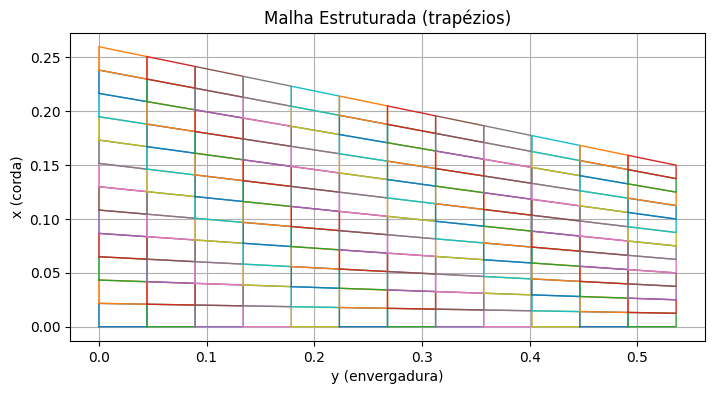

In [16]:

# Malha inicial apenas para visualização
nx_struct_preview = 12
ny_struct_preview = 12

nodes_preview, quads_preview, _ = generate_structured_trapezoidal_mesh(
    b=b, c_root=c_root, c_tip=c_tip,
    nx=nx_struct_preview, ny=ny_struct_preview
)


def plot_mesh_2d_structured(nodes, quads, title="Malha Estruturada (trapézios)"):

    plt.figure(figsize=(9,4))

    for q in quads:
        P = nodes[q][:, :2]
        P = np.vstack([P, P[0]])
        plt.plot(P[:,1], P[:,0], linewidth=1)  # y vira x, x vira y

    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("y (envergadura)")
    plt.ylabel("x (corda)")
    plt.title(title)
    plt.show()


# ----- plotar -----
print("Número de nós:", len(nodes_preview))
print("Número de elementos (quads):", len(quads_preview))
plot_mesh_2d_structured(nodes_preview, quads_preview)



# Capítulo 3 — Modelo estrutural

O modelo estrutural é uma placa de Mindlin com elemento QUAD4. Para cada elemento, calculamos:

- a matriz de rigidez elementar $K_e$;
- a matriz de massa elementar $M_e$.

A rigidez é composta por duas parcelas:

$
K_e = K_e^{bending} + K_e^{shear}
$

onde a parte de flexão usa a matriz constitutiva da placa e a parte de cisalhamento é integrada com redução de integração para evitar *locking*.

A massa é obtida por integração consistente:

$
M = \sum_e M_e
$

A montagem global gera as matrizes estruturais:

$
K = \sum_e K_e, \qquad M = \sum_e M_e
$

Após aplicar o engaste na raiz, resolvemos o problema generalizado de autovalor:

$
K_{ff}\,\phi = \omega^2 M_{ff}\,\phi
$

As frequências naturais são então dadas por:

$
f_n = \frac{\omega_n}{2\pi}
$

A seguir fazemos um estudo de convergência das três primeiras frequências naturais em função da discretização. O objetivo é escolher uma malha que já entregue frequências suficientemente estáveis sem deixar o custo computacional alto demais.


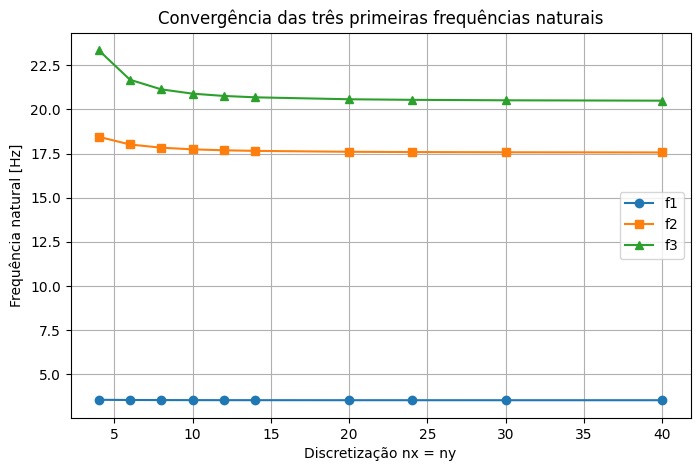

Tabela de convergência (nx = ny):
  n= 4 -> f1=  3.5502 Hz, f2= 18.4518 Hz, f3= 23.3569 Hz
  n= 6 -> f1=  3.5395 Hz, f2= 18.0160 Hz, f3= 21.6828 Hz
  n= 8 -> f1=  3.5344 Hz, f2= 17.8336 Hz, f3= 21.1385 Hz
  n=10 -> f1=  3.5317 Hz, f2= 17.7409 Hz, f3= 20.8957 Hz
  n=12 -> f1=  3.5301 Hz, f2= 17.6874 Hz, f3= 20.7660 Hz
  n=14 -> f1=  3.5291 Hz, f2= 17.6535 Hz, f3= 20.6883 Hz
  n=20 -> f1=  3.5276 Hz, f2= 17.6025 Hz, f3= 20.5783 Hz
  n=24 -> f1=  3.5271 Hz, f2= 17.5870 Hz, f3= 20.5458 Hz
  n=30 -> f1=  3.5267 Hz, f2= 17.5746 Hz, f3= 20.5194 Hz
  n=40 -> f1=  3.5264 Hz, f2= 17.5654 Hz, f3= 20.4990 Hz


In [18]:

mesh_list = [4, 6, 8, 10, 12, 14, 20, 24, 30, 40]
conv_results = []

for nxy in mesh_list:
    nodes_i, quads_i, _ = generate_structured_trapezoidal_mesh(
        b=b, c_root=c_root, c_tip=c_tip, nx=nxy, ny=nxy
    )
    K_i, M_i = assemble_KM_mindlin_quad4(
        nodes_i, quads_i,
        E=E, nu=nu, h=h_plate, rho=rho_struct, kappa=kappa_shear
    )
    Kff_i, Mff_i, free_i, *_ = apply_clamped_root_bc_mindlin(nodes_i, K_i, M_i)
    omega_i, _ = solve_modes(Kff_i, Mff_i, n_modes=3, sigma=0.0)
    freq_i = omega_i / (2.0 * np.pi)
    conv_results.append((nxy, *freq_i))

conv_results = np.array(conv_results)

plt.figure(figsize=(8, 5))
plt.plot(conv_results[:,0], conv_results[:,1], 'o-', label='f1')
plt.plot(conv_results[:,0], conv_results[:,2], 's-', label='f2')
plt.plot(conv_results[:,0], conv_results[:,3], '^-', label='f3')
plt.xlabel('Discretização nx = ny')
plt.ylabel('Frequência natural [Hz]')
plt.title('Convergência das três primeiras frequências naturais')
plt.legend()
plt.show()

print('Tabela de convergência (nx = ny):')
for row in conv_results:
    print(f"  n={int(row[0]):2d} -> f1={row[1]:8.4f} Hz, f2={row[2]:8.4f} Hz, f3={row[3]:8.4f} Hz")



Com base no gráfico de convergência, escolhemos uma discretização final para o restante do notebook.
A proposta abaixo parte da ideia de que a malha deve ser refinada o suficiente para estabilizar as três primeiras frequências, mas ainda permitir uma varredura aeroelástica eficiente.


In [ ]:

# Discretização estrutural proposta após o estudo de convergência
nx_struct = 12
ny_struct = 12

nodes_s, quads_s, _ = generate_structured_trapezoidal_mesh(
    b=b, c_root=c_root, c_tip=c_tip,
    nx=nx_struct, ny=ny_struct
)

K, M = assemble_KM_mindlin_quad4(
    nodes_s, quads_s,
    E=E, nu=nu, h=h_plate, rho=rho_struct, kappa=kappa_shear
)

Kff, Mff, free, fixed, root_nodes = apply_clamped_root_bc_mindlin(
    nodes_s, K, M, y_root=0.0, tol=1e-10
)

omega_n, Phi_red = solve_modes(Kff, Mff, n_modes=4, sigma=0.0)
Phi_full = recover_full_modes(Phi_red, free, K.shape[0])
freq_hz = omega_n / (2.0 * np.pi)

print(f'Discretização estrutural adotada: {nx_struct} x {ny_struct}')
print('Primeiras frequências naturais:')
for i, f in enumerate(freq_hz[:3], start=1):
    print(f'  modo {i}: {f:.4f} Hz')


Discretização estrutural adotada: 12 x 12
Primeiras frequências naturais:
  modo 1: 17.6874 Hz
  modo 2: 20.7660 Hz
  modo 3: 50.6726 Hz


In [37]:
save_first_modes_gifs(
    nodes=nodes_s,
    quads=quads_s,
    Phi_full=Phi_full,
    freq_hz=freq_hz,
    mode_ids=(1, 2, 3, 4),
    amp=0.08,
    out_dir="gifs_modos"
)

GIF salvo em: gifs_modos/modo_2.gif
GIF salvo em: gifs_modos/modo_3.gif
GIF salvo em: gifs_modos/modo_4.gif


IndexError: list index out of range


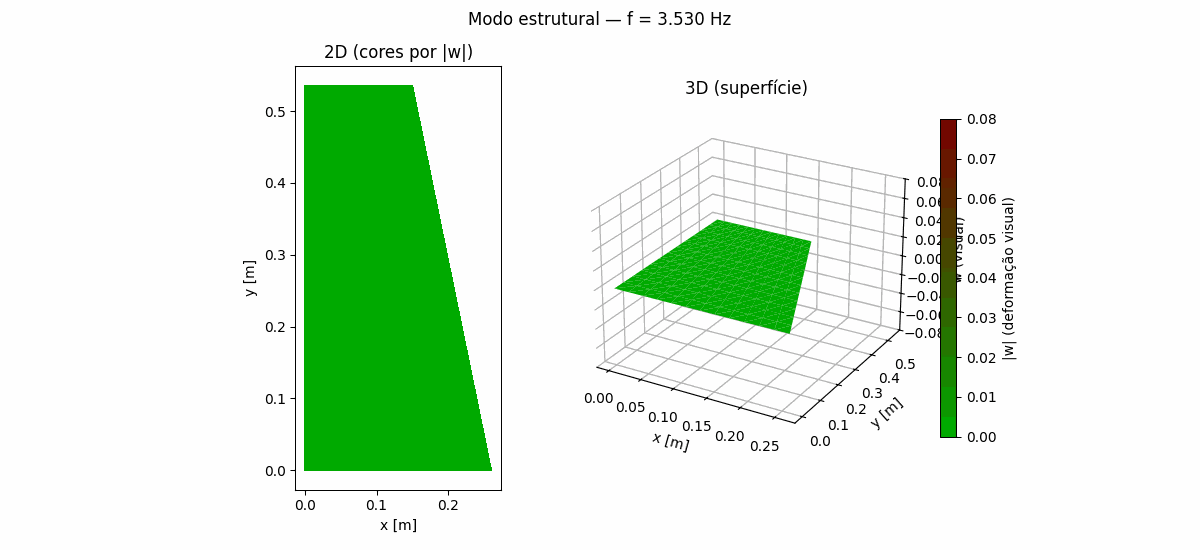
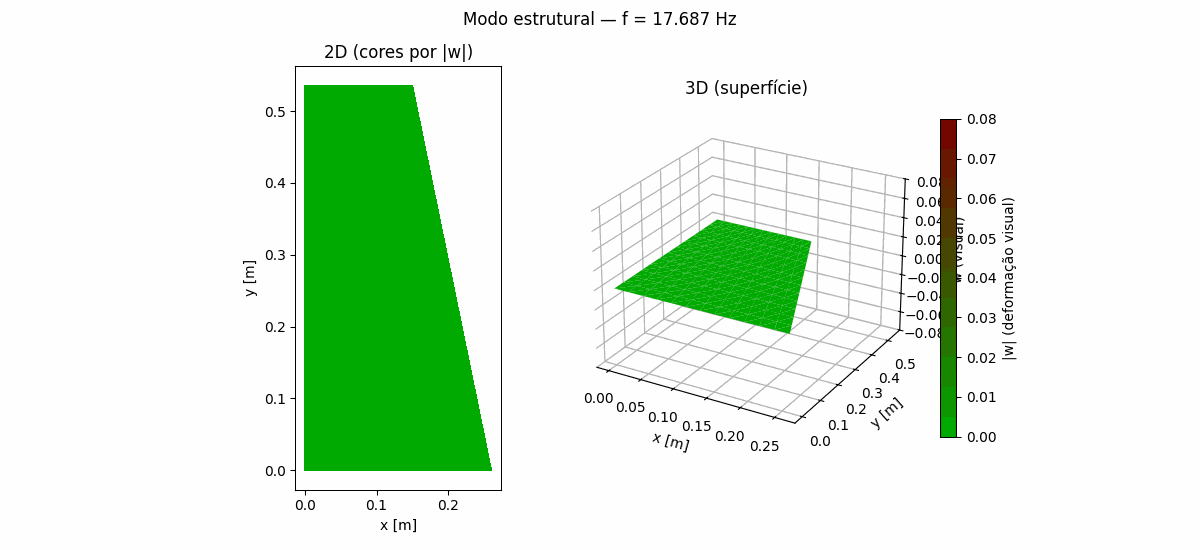
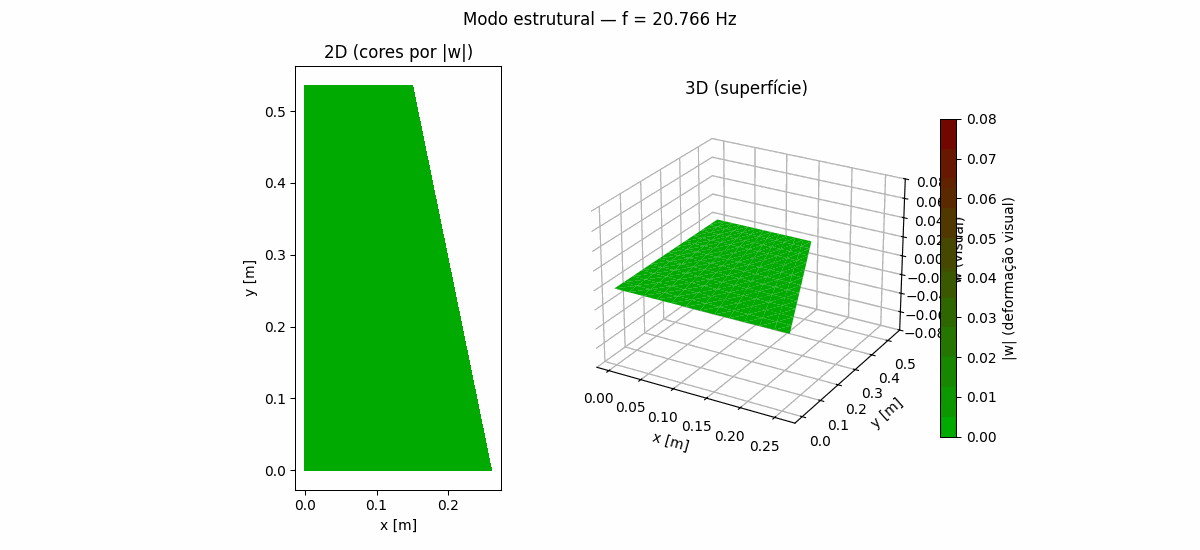
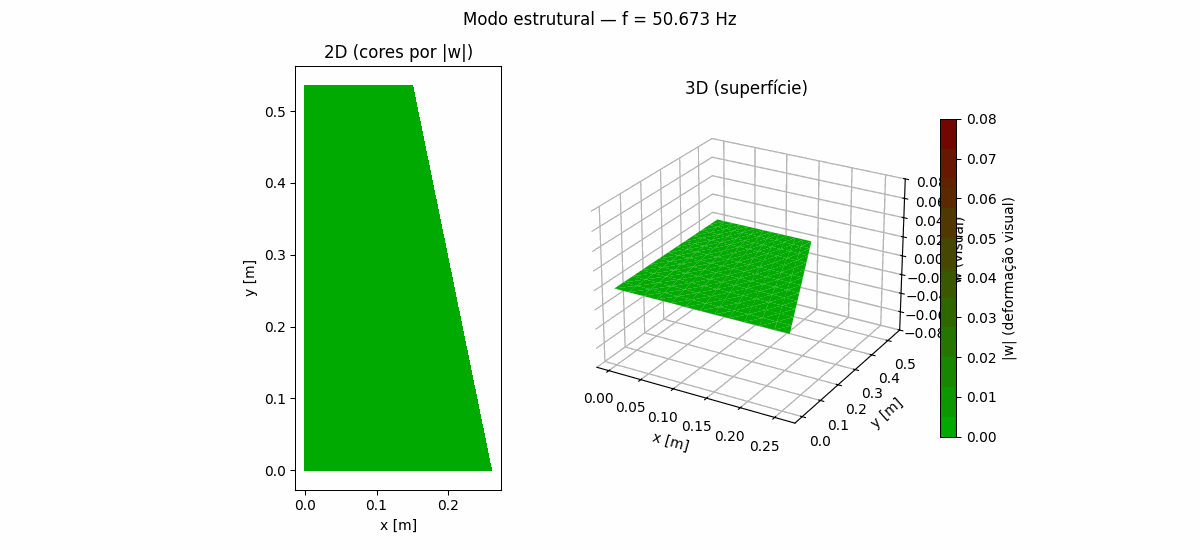

In [ ]:


from pathlib import Path

gif_dir = Path("gifs_modos")
gif_paths = sorted(gif_dir.glob("*.gif"))

show_gifs_html(
    gif_paths=gif_paths,
    titles=[p.stem.replace("_", " ").title() for p in gif_paths],
    width=420,
    columns=2,
)


# Capítulo 4 — Modelo aerodinâmico escolhido: DLM

O modelo aerodinâmico adotado é o **Doublet Lattice Method (DLM)**, apropriado para análise aeroelástica linear em regime subsônico.
A ideia central é construir uma matriz aerodinâmica complexa que relaciona a cinemática da superfície às cargas aerodinâmicas harmônicas.

No modelo usado neste notebook, a biblioteca `PanelAero` é responsável por calcular a matriz de influência aerodinâmica do DLM para a malha de painéis aerodinâmicos.
Essa escolha foi feita porque a biblioteca já implementa o DLM de forma padronizada e permite usar diretamente uma malha de painéis com os pontos geométricos característicos do método.

A malha aerodinâmica será construída sobre a mesma planta trapezoidal, mas com discretização própria. Como o caso é de **meia asa**, usamos simetria no plano $xz$ no cálculo aerodinâmico.


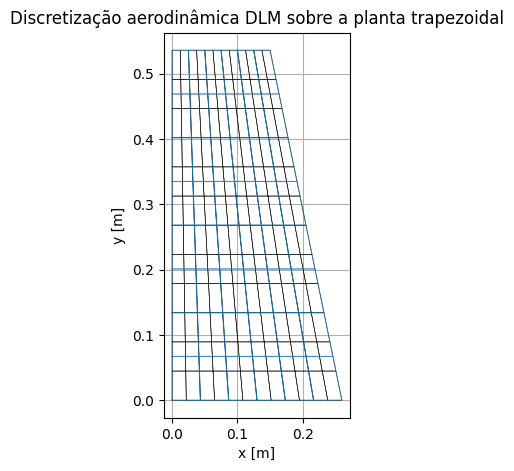

Malha aerodinâmica adotada: 6 x 8
Número de painéis aerodinâmicos: 48
Usando simetria xz no DLM: True


In [6]:

# Parâmetros aerodinâmicos
rho_air = 1.225
mach = 0.0
nx_aero = 6
ny_aero = 8
use_xz_symmetry = True

boxes_a = generate_aero_boxes(b, c_root, c_tip, nx=nx_aero, ny=ny_aero)
aero_geos = [box_geometry(bx) for bx in boxes_a]
aerogrid = build_panelaero_aerogrid(aero_geos)

fig, ax = plt.subplots(figsize=(8, 5))
plot_mesh(nodes_s, quads_s, ax=ax, title='Malha estrutural + malha aerodinâmica')
for g in aero_geos:
    bx = g['box']
    loop = np.vstack([bx, bx[0]])
    ax.plot(loop[:, 0], loop[:, 1], color='tab:blue', lw=0.8, alpha=0.6)
ax.set_title('Discretização aerodinâmica DLM sobre a planta trapezoidal')
plt.show()

print(f'Malha aerodinâmica adotada: {nx_aero} x {ny_aero}')
print(f'Número de painéis aerodinâmicos: {aerogrid["n"]}')
print(f'Usando simetria xz no DLM: {use_xz_symmetry}')



# Capítulo 5 — Acoplamento entre o modelo estrutural e o modelo aerodinâmico

O acoplamento entre a estrutura e o modelo aerodinâmico é feito em **coordenadas modais**.  
A ideia central é a seguinte:

1. a estrutura fornece a deformação da asa;
2. essa deformação gera um *downwash* nos painéis aerodinâmicos;
3. o DLM transforma esse *downwash* em distribuição de pressão complexa;
4. as pressões são convertidas em forças de painel;
5. essas forças são projetadas de volta para o espaço modal estrutural.

---



## 5.1 Equação estrutural no espaço físico

O problema estrutural discreto por elementos finitos pode ser escrito como

$$
\mathbf{M}\,\ddot{\mathbf{q}}(t)
+
\mathbf{C}\,\dot{\mathbf{q}}(t)
+
\mathbf{K}\,\mathbf{q}(t)
=
\mathbf{f}_a(t)
$$

onde:

- $\mathbf{M}$ é a matriz global de massa;
- $\mathbf{C}$ é a matriz global de amortecimento;
- $\mathbf{K}$ é a matriz global de rigidez;
- $\mathbf{q}(t)$ é o vetor de graus de liberdade estruturais;
- $\mathbf{f}_a(t)$ é o vetor de forças aerodinâmicas equivalentes.


No presente modelo, cada nó estrutural possui os graus de liberdade

$$
[w,\ \theta_x,\ \theta_y]
$$

de modo que o vetor $$\mathbf{q}(t)$$ contém deslocamentos transversais e rotações da placa.

---



## 5.2 Redução modal

Em vez de resolver o problema completo em todos os graus de liberdade, projetamos a resposta em uma base modal reduzida. Escrevemos

$$
\mathbf{q}(t)=\mathbf{\Phi}\,\boldsymbol{\eta}(t)
$$

onde:

- $\mathbf{\Phi}\in\mathbb{R}^{N_{dof}\times m}$ é a matriz modal, cujas colunas são os modos estruturais retidos;
- $\boldsymbol{\eta}(t)\in\mathbb{R}^{m}$ é o vetor de coordenadas modais;
- $m$ é o número de modos usados no acoplamento.

Como os modos foram normalizados pela massa, temos aproximadamente

$$
\mathbf{\Phi}^T \mathbf{M}\mathbf{\Phi}=\mathbf{I}
$$

e a matriz modal de rigidez fica

$$
\mathbf{\Phi}^T\mathbf{K}\mathbf{\Phi}=\mathbf{\Omega}^2
$$

com

$$
\mathbf{\Omega}=
\mathrm{diag}(\omega_1,\omega_2,\ldots,\omega_m)
$$

sendo a matriz diagonal das frequências naturais.

Adotando amortecimento modal proporcional,

$$
\mathbf{\Phi}^T\mathbf{C}\mathbf{\Phi}
=
2\,\mathbf{\Xi}\,\mathbf{\Omega}
$$

onde

$$
\mathbf{\Xi}=
\mathrm{diag}(\zeta_1,\zeta_2,\ldots,\zeta_m)
$$

é a matriz diagonal de amortecimentos modais.

Substituindo $$\mathbf{q}(t)=\mathbf{\Phi}\,\boldsymbol{\eta}(t)$$ na equação estrutural e pré-multiplicando por $$\mathbf{\Phi}^T$$, obtemos o sistema modal

$$
\ddot{\boldsymbol{\eta}}(t)
+
2\,\mathbf{\Xi}\,\mathbf{\Omega}\,\dot{\boldsymbol{\eta}}(t)
+
\mathbf{\Omega}^2\,\boldsymbol{\eta}(t)
=
\mathbf{\Phi}^T \mathbf{f}_a(t)
$$

Portanto, o problema passa a ser determinar a força aerodinâmica generalizada

$$
\mathbf{Q}_a(t)=\mathbf{\Phi}^T \mathbf{f}_a(t)
$$

---



## 5.3 Cinemática estrutural nos painéis aerodinâmicos

O DLM não trabalha diretamente com os graus de liberdade estruturais, mas sim com o *downwash* imposto nos painéis aerodinâmicos.

Para isso, calculamos três operadores de acoplamento:

- $\mathbf{H}_c\in\mathbb{R}^{N_p\times m}$: deslocamento modal no ponto de colocation de cada painel;
- $\mathbf{H}_x\in\mathbb{R}^{N_p\times m}$: derivada $\partial w/\partial x$ no ponto de colocation;
- $\mathbf{F}_{map}\in\mathbb{R}^{m\times N_p}$: operador de projeção por trabalho virtual das forças de painel para forças modais.

Aqui $N_p$ é o número de painéis aerodinâmicos.

Para um modo harmônico, assumimos

$$
\boldsymbol{\eta}(t)=\hat{\boldsymbol{\eta}}\,e^{i\omega t}
$$

o que implica

$$
\mathbf{q}(t)=\mathbf{\Phi}\,\hat{\boldsymbol{\eta}}\,e^{i\omega t}
$$

Assim, o *downwash* complexo nos painéis pode ser escrito como

$$
\hat{\mathbf{w}}_j
=
s_w
\left(
\mathbf{H}_x
+
i\,k\,\mathbf{H}_c
\right)
\hat{\boldsymbol{\eta}}
$$

onde:

- $\hat{\mathbf{w}}_j\in\mathbb{C}^{N_p}$ é o vetor de *downwash* nos painéis;
- $k=\omega/U$ é a frequência aerodinâmica usada na implementação do DLM da biblioteca;
- $U$ é a velocidade de voo;
- $s_w\in\{-1,+1\}$ é o sinal adotado para compatibilizar a convenção estrutural com a convenção aerodinâmica.

No código final, esse termo aparece como

$$
\hat{\mathbf{w}}_j
=
s_w
\left(
\mathbf{H}_x
+
i\,k\,\mathbf{H}_c
\right)
\hat{\boldsymbol{\eta}}
$$
S
e corresponde exatamente ao vetor chamado `wj`.

---



## 5.4 Equação matricial aerodinâmica do DLM

O DLM fornece uma matriz de influência aerodinâmica complexa

$$
\mathbf{Q}_{jj}(k,M)\in\mathbb{C}^{N_p\times N_p}
$$

que relaciona o *downwash* nos painéis com o salto de pressão adimensional, aqui representado pelo vetor de coeficientes de pressão complexos:

$$
\Delta \hat{\mathbf{c}}_p
=
\mathbf{Q}_{jj}(k,M)\,\hat{\mathbf{w}}_j
$$

onde:

- $M$ é o número de Mach;
- $\Delta \hat{\mathbf{c}}_p\in\mathbb{C}^{N_p}$ contém os coeficientes de pressão complexos em cada painel.

Substituindo a expressão do *downwash*:

$$
\Delta \hat{\mathbf{c}}_p
=
\mathbf{Q}_{jj}(k,M)\,
s_w
\left(
\mathbf{H}_x
+
i\,k\,\mathbf{H}_c
\right)
\hat{\boldsymbol{\eta}}
$$

---



## 5.5 Forças de painel

Cada coeficiente de pressão é convertido em força de painel multiplicando-se pela pressão dinâmica e pela área do painel.  
Definimos a pressão dinâmica como

$$
q_\infty=\frac{1}{2}\rho_{ar}U^2
$$

e uma matriz diagonal geométrica

$$
\mathbf{A}_n
=
\mathrm{diag}
\left(
A_1 n_{z,1},
A_2 n_{z,2},
\ldots,
A_{N_p} n_{z,N_p}
\right)
$$

onde:

- $A_j$ é a área do painel $j$;
- $n_{z,j}$ é a componente vertical da normal do painel $j$.

Incluindo o sinal de convenção da força, $s_f\in\{-1,+1\}$, o vetor complexo de forças de painel fica

$$
\hat{\mathbf{f}}_p
=
q_\infty\,
s_f\,
\mathbf{A}_n\,
\Delta \hat{\mathbf{c}}_p
$$

Substituindo a expressão da pressão:

$$
\hat{\mathbf{f}}_p
=
q_\infty\,
s_f\,
\mathbf{A}_n\,
\mathbf{Q}_{jj}(k,M)\,
s_w
\left(
\mathbf{H}_x
+
i\,k\,\mathbf{H}_c
\right)
\hat{\boldsymbol{\eta}}
$$

---



## 5.6 Projeção das forças de painel para o espaço modal

O vetor de forças aerodinâmicas generalizadas no espaço modal é obtido por

$$
\hat{\mathbf{Q}}_a
=
\mathbf{F}_{map}\,\hat{\mathbf{f}}_p
$$

Logo,

$$
\hat{\mathbf{Q}}_a
=
q_\infty\,
\mathbf{F}_{map}\,
s_f\,
\mathbf{A}_n\,
\mathbf{Q}_{jj}(k,M)\,
s_w
\left(
\mathbf{H}_x
+
i\,k\,\mathbf{H}_c
\right)
\hat{\boldsymbol{\eta}}
$$

Agrupando tudo, obtemos a matriz aerodinâmica modal complexa

$$
\hat{\mathbf{Q}}_a
=
\mathbf{Q}_a(k,U)\,\hat{\boldsymbol{\eta}}
$$

com

$$
\mathbf{Q}_a(k,U)
=
q_\infty\,
\mathbf{F}_{map}\,
s_f\,
\mathbf{A}_n\,
\mathbf{Q}_{jj}(k,M)\,
s_w
\left(
\mathbf{H}_x
+
i\,k\,\mathbf{H}_c
\right)
$$

Essa é a **equação matricial completa do acoplamento aeroelástico modal** usada no código.

---



## 5.7 Dimensões das matrizes

Para deixar a formulação completamente clara, as dimensões das principais matrizes são:

$$
\mathbf{H}_c,\mathbf{H}_x \in \mathbb{R}^{N_p\times m}
$$

$$
\mathbf{Q}_{jj}(k,M)\in\mathbb{C}^{N_p\times N_p}
$$

$$
\mathbf{A}_n\in\mathbb{R}^{N_p\times N_p}
$$

$$
\mathbf{F}_{map}\in\mathbb{R}^{m\times N_p}
$$

$$
\mathbf{Q}_a(k,U)\in\mathbb{C}^{m\times m}
$$

Portanto, a cadeia de multiplicações é

$$
\underbrace{\mathbf{Q}_a(k,U)}_{m\times m}
=
q_\infty
\underbrace{\mathbf{F}_{map}}_{m\times N_p}
\underbrace{\left(s_f\mathbf{A}_n\right)}_{N_p\times N_p}
\underbrace{\mathbf{Q}_{jj}(k,M)}_{N_p\times N_p}
\underbrace{\left[s_w\left(\mathbf{H}_x+i\,k\,\mathbf{H}_c\right)\right]}_{N_p\times m}
$$

o que resulta corretamente em uma matriz modal aerodinâmica de dimensão $$m\times m$$.

---



## 5.8 Equação aeroelástica final no espaço modal

Finalmente, o problema estrutural reduzido com a força aerodinâmica acoplada pode ser escrito como

$$
\ddot{\boldsymbol{\eta}}(t)
+
2\,\mathbf{\Xi}\,\mathbf{\Omega}\,\dot{\boldsymbol{\eta}}(t)
+
\mathbf{\Omega}^2\,\boldsymbol{\eta}(t)
-
\mathbf{Q}_a(k,U)\,\boldsymbol{\eta}(t)
=
0
$$

Para solução harmônica/complexa, isso conduz ao problema aeroelástico

$$
\left[
\lambda^2 \mathbf{I}
+
\lambda\left(2\,\mathbf{\Xi}\,\mathbf{\Omega}\right)
+
\mathbf{\Omega}^2
-
\mathbf{Q}_a(k,U)
\right]
\hat{\boldsymbol{\eta}}
=
0
$$

onde:

- $\lambda\in\mathbb{C}$ é o autovalor aeroelástico;
- $\Re(\lambda)$ define estabilidade ou instabilidade;
- $\Im(\lambda)$ define a frequência de oscilação.

É essa equação que será resolvida no capítulo seguinte para rastrear os *branches* aeroelásticos e determinar a velocidade de flutter.


User action: Always define panels from left to right.
User action: Always define panels from left to right.
User action: Always define panels from left to right.
User action: Always define panels from left to right.
User action: Always define panels from left to right.
User action: Always define panels from left to right.
User action: Always define panels from left to right.
User action: Always define panels from left to right.
User action: Always define panels from left to right.
User action: Always define panels from left to right.
User action: Always define panels from left to right.
User action: Always define panels from left to right.
User action: Always define panels from left to right.
User action: Always define panels from left to right.
User action: Always define panels from left to right.
User action: Always define panels from left to right.
User action: Always define panels from left to right.
User action: Always define panels from left to right.
User action: Always define p

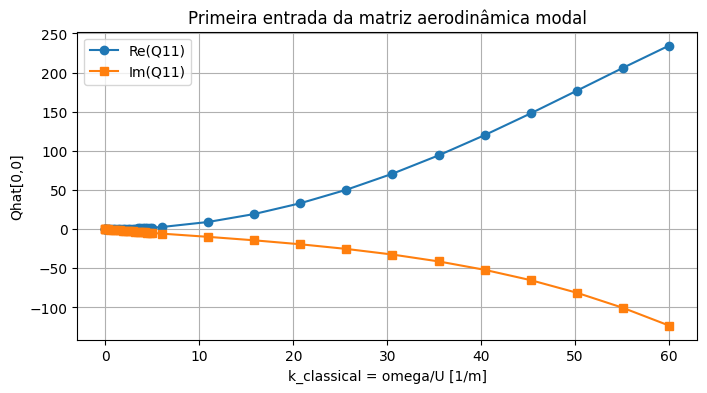

In [19]:

Hc, Hx, Fmap = build_modal_aero_operators(
    nodes_s, quads_s, Phi_full, aero_geos
)

# Sinais adotados no acoplamento
# Eles foram ajustados para evitar comportamento patológico do crescimento modal.
downwash_sign = -1.0
force_sign = 1.0

# Faixa de frequências clássicas do DLM: k = omega / U
k_classical_grid = np.concatenate((
    [1e-4, 5e-4, 1e-3],
    np.linspace(0.01, 5.0, 20),
    np.linspace(6.0, 60.0, 12),
))

Qhat_grid = build_panelaero_modal_Qhat(
    aerogrid=aerogrid,
    Hc=Hc,
    Hx=Hx,
    Fmap=Fmap,
    k_classical_grid=k_classical_grid,
    mach=mach,
    xz_symmetry=use_xz_symmetry,
    downwash_sign=downwash_sign,
    force_sign=force_sign,
)

aero_model = PanelAeroDLMModalModel(
    k_classical_grid=k_classical_grid,
    Qhat_grid=Qhat_grid,
    rho_air=rho_air,
)

plt.figure(figsize=(8, 4))
plt.plot(k_classical_grid, Qhat_grid[:, 0, 0].real, 'o-', label='Re(Q11)')
plt.plot(k_classical_grid, Qhat_grid[:, 0, 0].imag, 's-', label='Im(Q11)')
plt.xlabel('k_classical = omega/U [1/m]')
plt.ylabel('Qhat[0,0]')
plt.title('Primeira entrada da matriz aerodinâmica modal')
plt.legend()
plt.show()



# Capítulo 6 — Como foi encontrada a velocidade de flutter

A velocidade de flutter foi obtida com uma varredura em velocidade usando um procedimento de *branch tracking*.

Para cada velocidade $U$, o sistema aeroelástico linearizado fornece autovalores complexos:

$
\lambda = \sigma + i\omega
$

onde:

- $\sigma = \Re(\lambda)$ indica crescimento ou decaimento;
- $\omega = \Im(\lambda)$ é a frequência oscilatória do *branch*.

Cada **branch** é uma ramificação aeroelástica acompanhada ao longo da velocidade. No início da varredura, cada branch nasce a partir de uma frequência estrutural. Depois disso, ele é acompanhado por continuidade numérica em velocidade.

O flutter ocorre quando algum branch cruza o eixo:

$
\Re(\lambda) = 0
$

ou seja, quando o amortecimento efetivo deixa de ser negativo e a resposta passa a crescer.

Nesta etapa, vamos:

1. verificar o caso estrutural puro;
2. fazer a varredura aeroelástica rastreando os branches;
3. estimar a primeira velocidade em que algum branch cruza zero.


Autovalores estruturais puros (ramos com Im(lambda) > 0):
  branch 1: lambda = -1.109021e-01+2.218014e+01j
  branch 2: lambda = -5.556665e-01+1.111319e+02j
  branch 3: lambda = -6.523845e-01+1.304753e+02j
  branch 4: lambda = -1.591926e+00+3.183813e+02j
Em regime puramente estrutural, Re(lambda) deve ser negativo.


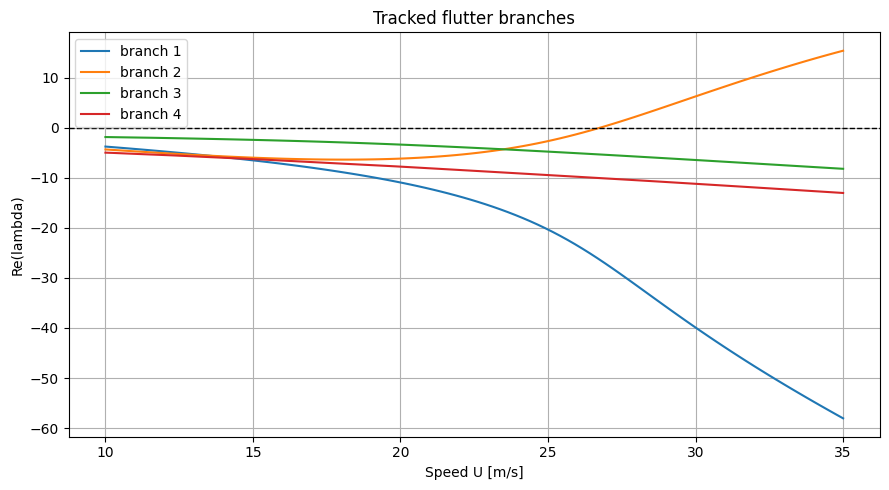

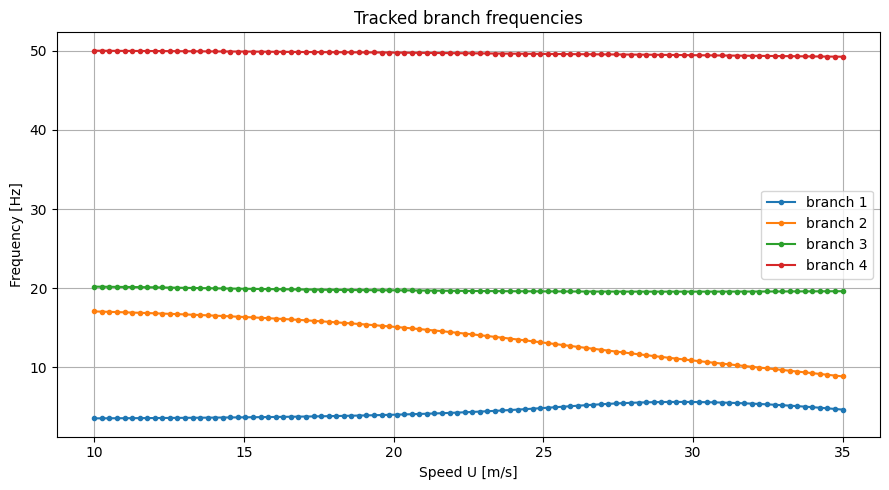

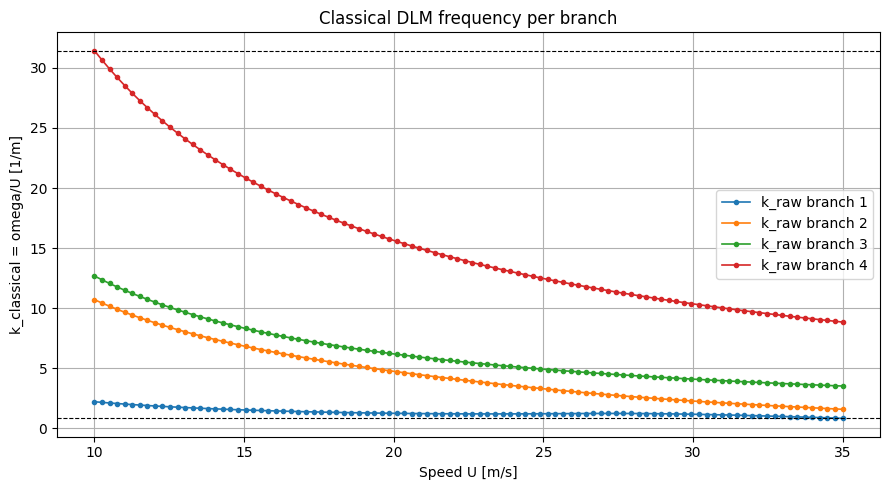

In [23]:

# Sanity check estrutural puro
lam_struct = structural_only_eigs(omega_n, zeta_struct)
print('Autovalores estruturais puros (ramos com Im(lambda) > 0):')
for i, lam in enumerate(lam_struct, start=1):
    print(f'  branch {i}: lambda = {lam:.6e}')
print('Em regime puramente estrutural, Re(lambda) deve ser negativo.')

# Varredura em velocidade
U_min = 10.0
U_max = 35.0
n_scan = 100
U_values = np.linspace(U_min, U_max, n_scan)

scan_results = flutter_scan_tracked(
    U_values=U_values,
    aero=aero_model,
    omega_n=omega_n,
    zeta=zeta_struct,
)

plot_flutter_branches(scan_results)

flutter_result = estimate_flutter_speed_from_branches(scan_results)



# Capítulo 7 — Resultados finais

Neste capítulo apresentamos:

- as três primeiras frequências naturais da estrutura discretizada;
- a velocidade de flutter obtida pelo primeiro cruzamento de $\Re(\lambda)=0$;
- uma interpretação física resumida do resultado.

A interpretação esperada é a seguinte:

- se os branches permanecem suaves e bem rastreados ao longo da velocidade, o método numérico está consistente;
- a velocidade de flutter corresponde ao primeiro branch que perde estabilidade;
- a frequência associada ao flutter ajuda a identificar o caráter dominante do modo aeroelástico crítico.


In [13]:

print('As três primeiras frequências naturais obtidas:')
for i, f in enumerate(freq_hz[:3], start=1):
    print(f'  f{i} = {f:.4f} Hz')

print()
if flutter_result is None:
    print('Nenhum cruzamento de flutter foi encontrado no intervalo varrido.')
else:
    print('Velocidade de flutter estimada:')
    print(f"  U_flutter        = {flutter_result['U_flutter']:.6f} m/s")
    print(f"  branch crítico   = {flutter_result['branch']}")
    print(f"  frequência       = {flutter_result['freq_hz']:.6f} Hz")
    print(f"  omega            = {flutter_result['omega']:.6f} rad/s")
    print(f"  k_classical_raw  = {flutter_result['k_classical_raw']:.6f} 1/m")
    print(f"  k_classical_used = {flutter_result['k_classical_used']:.6f} 1/m")
    print(f"  k_clipped        = {flutter_result['k_clipped']}")

    if flutter_result['k_clipped']:
        print('Observação: a frequência aerodinâmica foi clipada em algum ponto da interpolação.')
        print('Nesse caso, vale a pena ampliar a grade de k_classical para aumentar a robustez do resultado.')
    else:
        print('Interpretação: o flutter foi identificado como o primeiro branch cujo Re(lambda) cruzou zero.')
        print('Isso indica perda de estabilidade aeroelástica na frequência mostrada acima.')


As três primeiras frequências naturais obtidas:
  f1 = 3.5301 Hz
  f2 = 17.6874 Hz
  f3 = 20.7660 Hz

Velocidade de flutter estimada:
  U_flutter        = 26.773266 m/s
  branch crítico   = 2
  frequência       = 12.270815 Hz
  omega            = 77.099807 rad/s
  k_classical_raw  = 2.879875 1/m
  k_classical_used = 2.879875 1/m
  k_clipped        = False
Interpretação: o flutter foi identificado como o primeiro branch cujo Re(lambda) cruzou zero.
Isso indica perda de estabilidade aeroelástica na frequência mostrada acima.
